In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

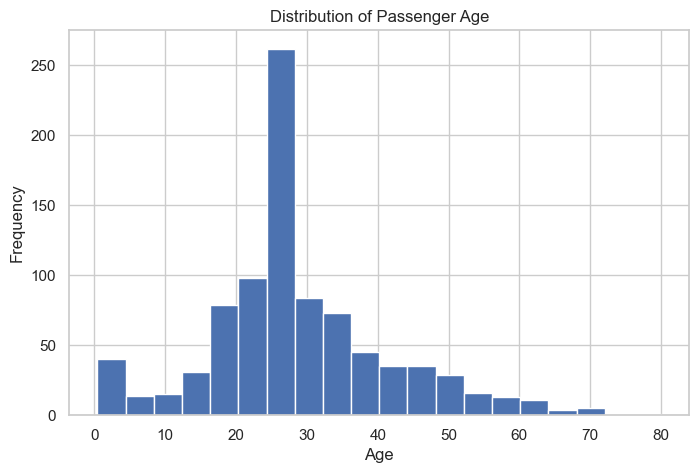

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Age")
plt.show()

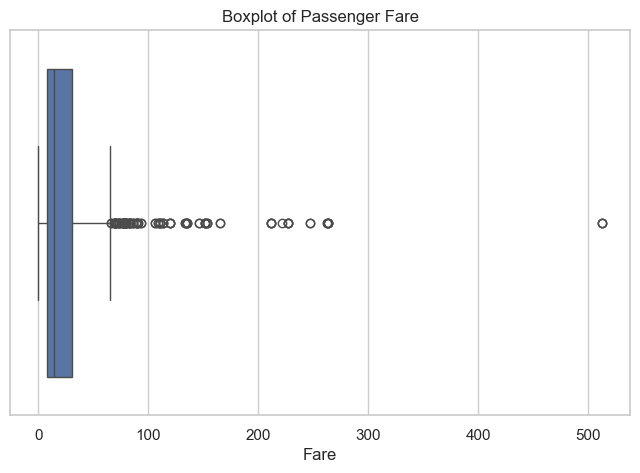

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["fare"])
plt.xlabel("Fare")
plt.title("Boxplot of Passenger Fare")
plt.show()

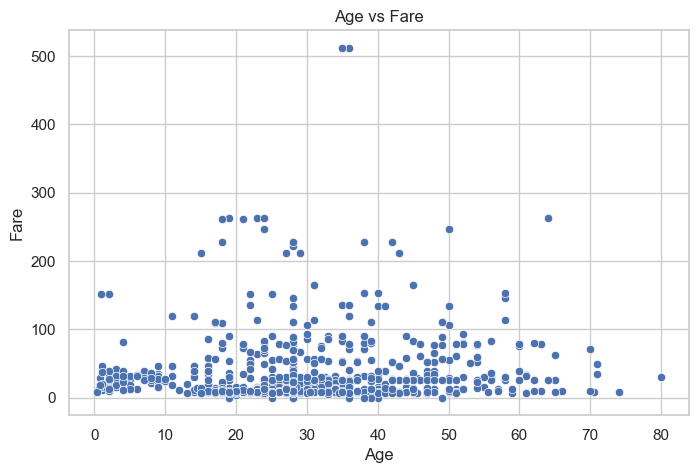

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

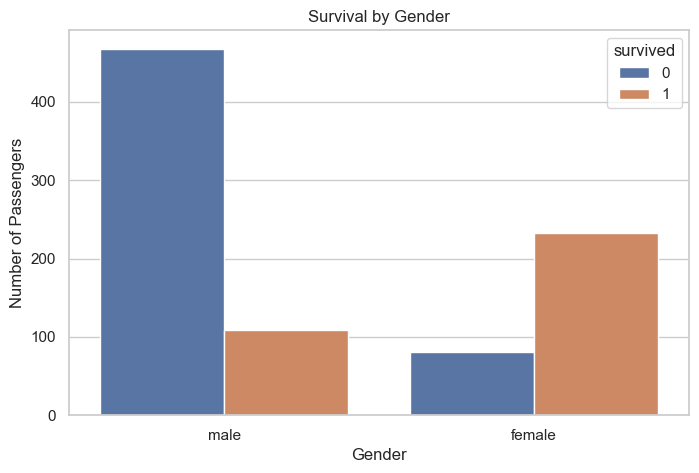

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [14]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

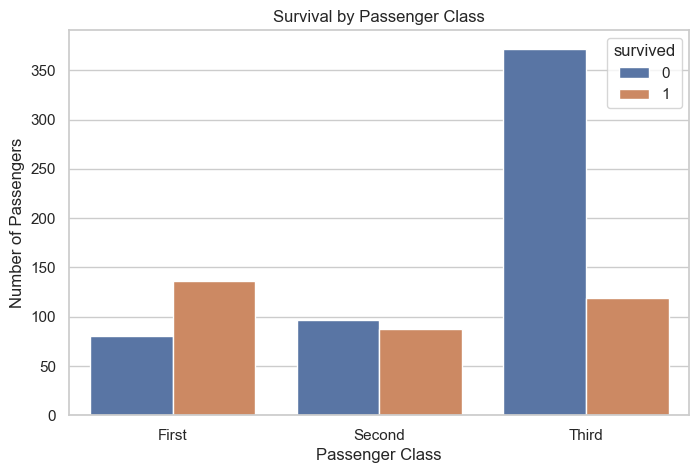

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="class", hue="survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

In [16]:
df.groupby("class")["survived"].mean()

C:\Users\hp pc\AppData\Local\Temp\ipykernel_25748\1782342418.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["survived"].mean()


class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

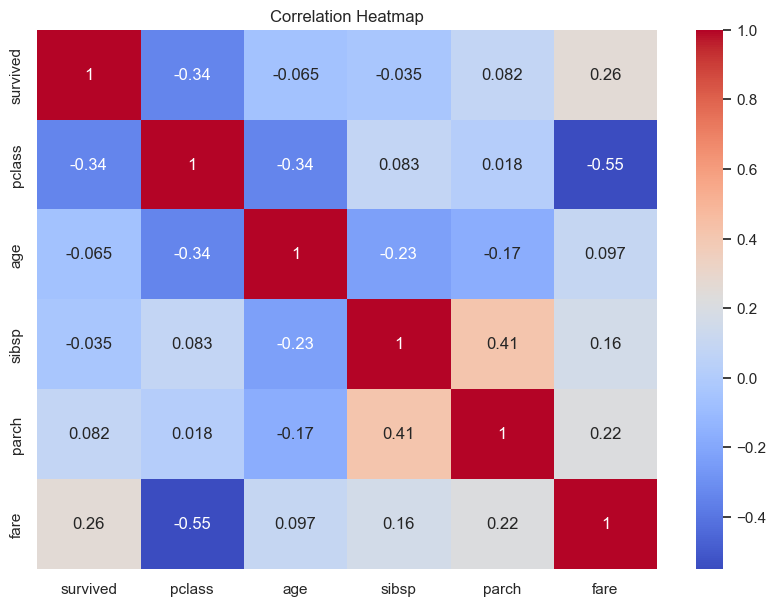

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

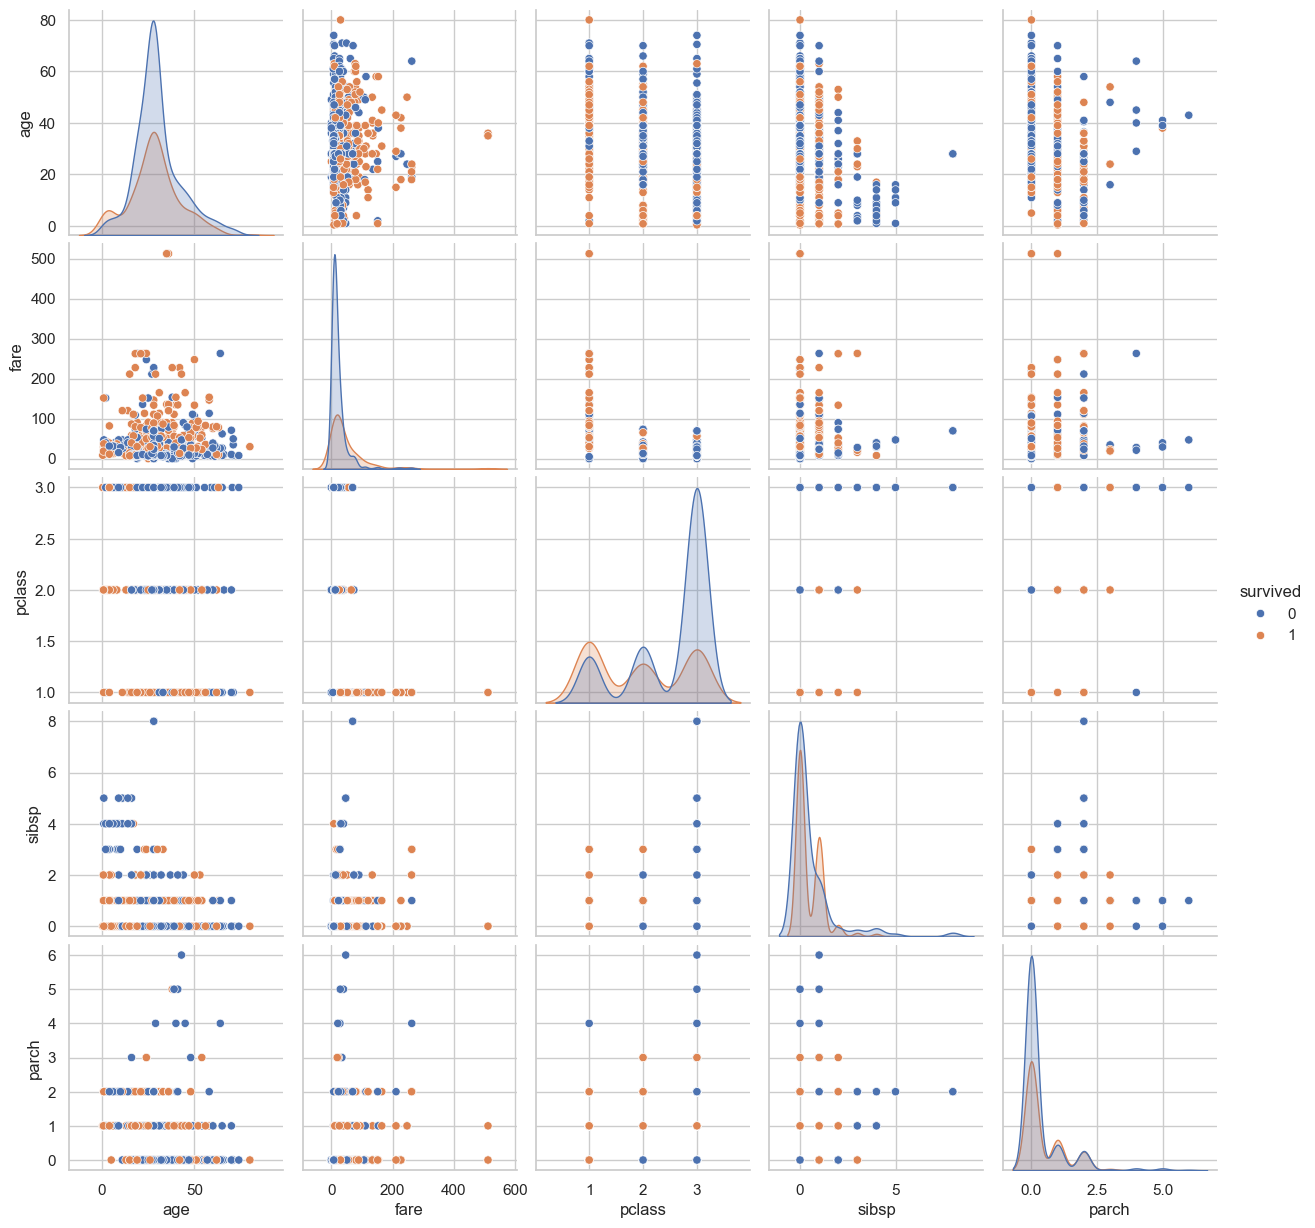

In [18]:
sns.pairplot(
    df[["survived", "age", "fare", "pclass", "sibsp", "parch"]].dropna(),
    hue="survived"
)
plt.show()

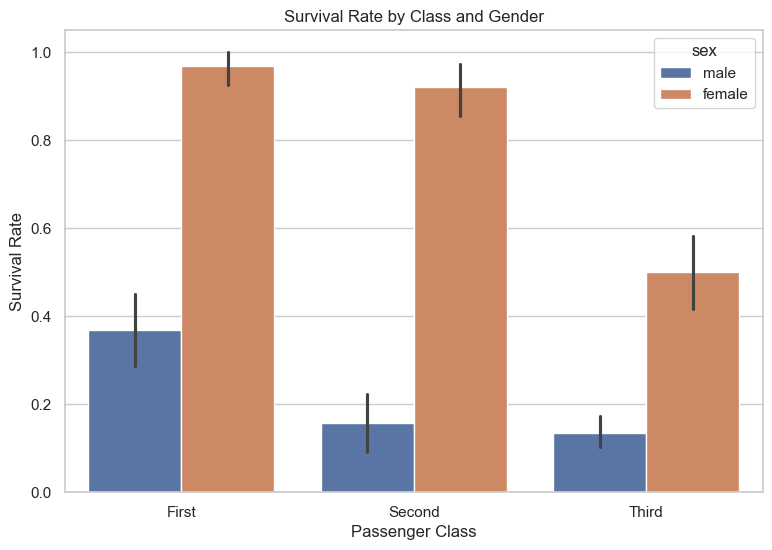

In [19]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=df,
    x="class",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

In [20]:
print("Overall Survival Rate:")
print(df["survived"].mean())

print("\nSurvival Rate by Gender:")
print(df.groupby("sex")["survived"].mean())

print("\nSurvival Rate by Class:")
print(df.groupby("class")["survived"].mean())

print("\nAverage Fare by Class:")
print(df.groupby("class")["fare"].mean())

Overall Survival Rate:
0.3838383838383838

Survival Rate by Gender:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Survival Rate by Class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Average Fare by Class:
class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64


C:\Users\hp pc\AppData\Local\Temp\ipykernel_25748\3635637453.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("class")["survived"].mean())
C:\Users\hp pc\AppData\Local\Temp\ipykernel_25748\3635637453.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("class")["fare"].mean())


## Key Findings

1. The Titanic dataset contains passenger information such as age, gender, passenger class, fare and survival status.

2. Missing values were identified and handled using median and mode imputation.

3. Female passengers generally had a higher survival rate than male passengers.

4. Passenger class had a noticeable relationship with survival rate, with higher-class passengers generally having better survival outcomes.

5. The fare distribution contains some potential outliers, which were identified using a boxplot.

6. The scatterplot helped examine the relationship between age and fare.

7. The correlation heatmap showed relationships among the numerical variables.

8. Pairplot and multivariate analysis helped identify relationships between multiple variables simultaneously.

## Conclusion

Exploratory Data Analysis was successfully performed on the Titanic dataset using Pandas, NumPy, Matplotlib and Seaborn. The analysis included data inspection, missing-value handling, descriptive statistics and multiple visualizations. Important patterns related to gender, passenger class, fare and survival were identified. EDA helped provide a better understanding of the dataset before further statistical or machine learning analysis.ss